# Redes Neuronales II — Notebook 03
## Clasificación multiclase en MNIST con TensorFlow + Keras (MLP, sin convoluciones)

**Objetivo.** Reconocer dígitos manuscritos (10 clases) con un **perceptrón multicapa totalmente conectado**. Cada imagen de 28×28 píxeles se aplana en un vector de 784 valores; no se usa ninguna capa convolucional.

| Elemento | Elección | Motivo |
|---|---|---|
| Entrada | 784 píxeles normalizados a [0, 1] | Escala homogénea para el gradiente |
| Capas ocultas | Dense 256 → Dense 128, **ReLU** | No satura, gradientes estables |
| Regularización | Dropout 0.2 tras cada capa oculta | Reduce co-adaptación / sobreajuste |
| Salida | Dense 10, **Softmax** | Distribución de probabilidad sobre los 10 dígitos |
| Pérdida | Entropía cruzada categórica (*sparse*) | Estándar en multiclase |
| Optimizador | Adam (η = 1e-3), lote 128 | Convergencia rápida y robusta |
| Parada | *EarlyStopping* (paciencia 3, restaura mejores pesos) | Evita sobreentrenar |

En Colab: `Entorno de ejecución → Ejecutar todas`. Funciona en CPU (≈ 1–2 min); con GPU es más rápido.

In [1]:
import os, json, time
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

SEED = 42
keras.utils.set_random_seed(SEED)
os.makedirs("figures", exist_ok=True); os.makedirs("results", exist_ok=True)
plt.rcParams.update({"figure.dpi": 110})
print("TensorFlow", tf.__version__, "| Keras", keras.__version__, "| GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow 2.21.0 | Keras 3.15.1 | GPU: []


## 1. Carga y preparación de MNIST
60 000 imágenes de entrenamiento y 10 000 de test. Se reservan las **últimas 6 000** de entrenamiento como validación (la misma partición se usa en el notebook de PyTorch para que la comparación sea justa).

train: (60000, 28, 28) test: (10000, 28, 28) | rango píxeles: 0 - 255


Formas finales: (54000, 784) (6000, 784) (10000, 784)
Distribución de clases (train): [5336 6112 5358 5504 5247 4872 5347 5597 5254 5373]


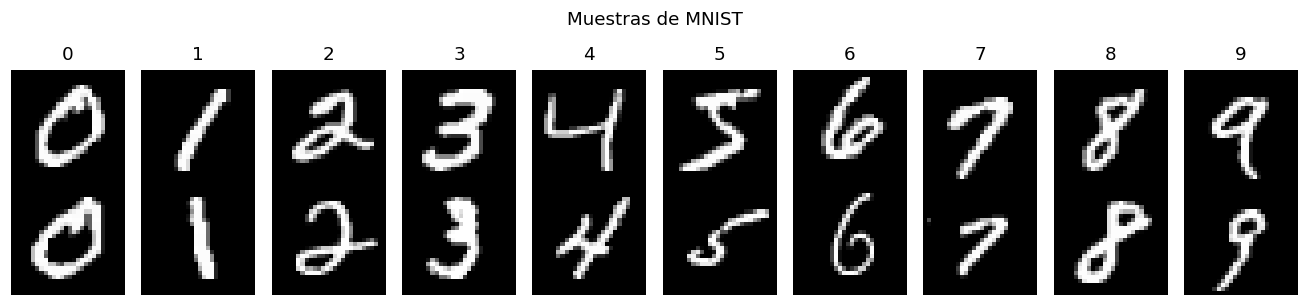

In [2]:
(x_train_full, y_train_full), (x_test, y_test) = keras.datasets.mnist.load_data()
print("train:", x_train_full.shape, "test:", x_test.shape, "| rango píxeles:", x_train_full.min(), "-", x_train_full.max())

def prep(x): return x.reshape(len(x), -1).astype("float32") / 255.0   # aplanar 28x28 -> 784 y normalizar

x_train, y_train = prep(x_train_full[:54000]), y_train_full[:54000]
x_val,   y_val   = prep(x_train_full[54000:]), y_train_full[54000:]
x_test_f         = prep(x_test)
print("Formas finales:", x_train.shape, x_val.shape, x_test_f.shape)
print("Distribución de clases (train):", np.bincount(y_train))

fig, axes = plt.subplots(2, 10, figsize=(12, 2.8))
for d in range(10):
    for r in range(2):
        idx = np.where(y_train_full == d)[0][r]
        axes[r, d].imshow(x_train_full[idx], cmap="gray"); axes[r, d].axis("off")
    axes[0, d].set_title(str(d))
plt.suptitle("Muestras de MNIST"); plt.tight_layout(); plt.savefig("figures/03_muestras_mnist.png", bbox_inches="tight"); plt.show()

## 2. Experimento: activación oculta Sigmoide vs ReLU
Misma arquitectura (784-256-128-10, sin dropout), mismo optimizador y 5 épocas; sólo cambia la activación oculta.

sigmoid: val_acc por época = [0.9358 0.9553 0.963  0.9665 0.9702]


   relu: val_acc por época = [0.9672 0.9752 0.9772 0.9752 0.9733]


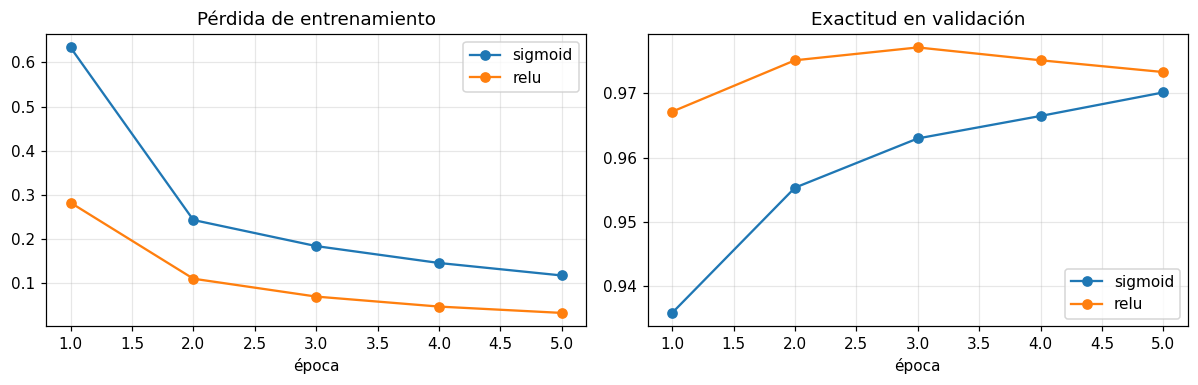

In [3]:
def build_mlp(activation="relu", dropout=0.2):
    layers = [keras.Input(shape=(784,))]
    for units in (256, 128):
        layers.append(keras.layers.Dense(units, activation=activation,
                                         kernel_initializer="he_normal" if activation == "relu" else "glorot_uniform"))
        if dropout: layers.append(keras.layers.Dropout(dropout))
    layers.append(keras.layers.Dense(10, activation="softmax"))
    model = keras.Sequential(layers, name=f"MLP_{activation}")
    model.compile(optimizer=keras.optimizers.Adam(1e-3), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

act_hist = {}
for act in ["sigmoid", "relu"]:
    keras.utils.set_random_seed(SEED)
    h = build_mlp(act, dropout=0).fit(x_train, y_train, validation_data=(x_val, y_val), epochs=5, batch_size=128, verbose=0)
    act_hist[act] = h.history
    print(f"{act:>7}: val_acc por época = {np.round(h.history['val_accuracy'], 4)}")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
for act, h in act_hist.items():
    ax[0].plot(range(1, 6), h["loss"], "o-", label=act); ax[1].plot(range(1, 6), h["val_accuracy"], "o-", label=act)
ax[0].set_title("Pérdida de entrenamiento"); ax[1].set_title("Exactitud en validación")
for a in ax: a.set_xlabel("época"); a.legend(); a.grid(alpha=0.3)
plt.tight_layout(); plt.savefig("figures/03_sigmoide_vs_relu.png", bbox_inches="tight"); plt.show()

## 3. Modelo final: MLP ReLU + Dropout

In [4]:
keras.utils.set_random_seed(SEED)
model = build_mlp("relu", dropout=0.2)
model.summary()

callbacks = [keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)]
t0 = time.time()
history = model.fit(x_train, y_train, validation_data=(x_val, y_val), epochs=30, batch_size=128,
                    callbacks=callbacks, verbose=2)
train_time = time.time() - t0
print(f"\nTiempo de entrenamiento: {train_time:.1f} s | épocas ejecutadas: {len(history.history['loss'])}")

Model: "MLP_relu"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

...

Epoch 11/30


422/422 - 2s - 4ms/step - accuracy: 0.9892 - loss: 0.0324 - val_accuracy: 0.9788 - val_loss: 0.0782


Epoch 12/30


422/422 - 2s - 5ms/step - accuracy: 0.9891 - loss: 0.0328 - val_accuracy: 0.9813 - val_loss: 0.0736



Tiempo de entrenamiento: 24.6 s | épocas ejecutadas: 12


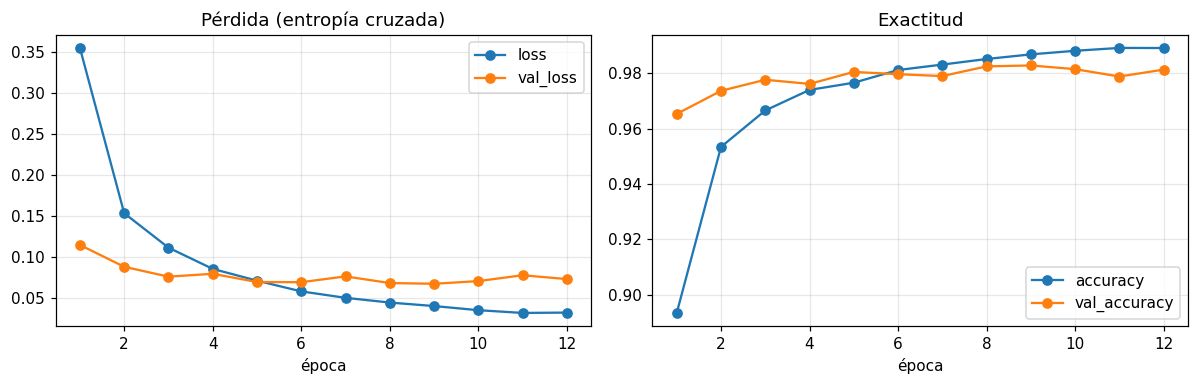

In [5]:
h = pd.DataFrame(history.history); h.index += 1
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
h[["loss", "val_loss"]].plot(ax=ax[0], marker="o", title="Pérdida (entropía cruzada)")
h[["accuracy", "val_accuracy"]].plot(ax=ax[1], marker="o", title="Exactitud")
for a in ax: a.set_xlabel("época"); a.grid(alpha=0.3)
plt.tight_layout(); plt.savefig("figures/03_curvas_keras.png", bbox_inches="tight"); plt.show()

## 4. Evaluación en test (10 000 imágenes nunca vistas)

In [6]:
test_loss, test_acc = model.evaluate(x_test_f, y_test, verbose=0)
probs = model.predict(x_test_f, verbose=0)
y_pred = probs.argmax(axis=1)
print(f"Pérdida test = {test_loss:.4f} | Exactitud test = {test_acc:.4f} | Errores = {(y_pred != y_test).sum()} de {len(y_test)}\n")
print(classification_report(y_test, y_pred, digits=4))

Pérdida test = 0.0626 | Exactitud test = 0.9822 | Errores = 178 de 10000

              precision    recall  f1-score   support

           0     0.9918    0.9867    0.9893       980
           1     0.9912    0.9930    0.9921      1135
           2     0.9750    0.9816    0.9783      1032
           3     0.9860    0.9782    0.9821      1010
           4     0.9848    0.9868    0.9858       982
           5     0.9886    0.9753    0.9819       892
           6     0.9834    0.9896    0.9865       958
           7     0.9804    0.9757    0.9781      1028
           8     0.9582    0.9877    0.9727       974
           9     0.9829    0.9663    0.9745      1009

    accuracy                         0.9822     10000
   macro avg     0.9822    0.9821    0.9821     10000
weighted avg     0.9823    0.9822    0.9822     10000



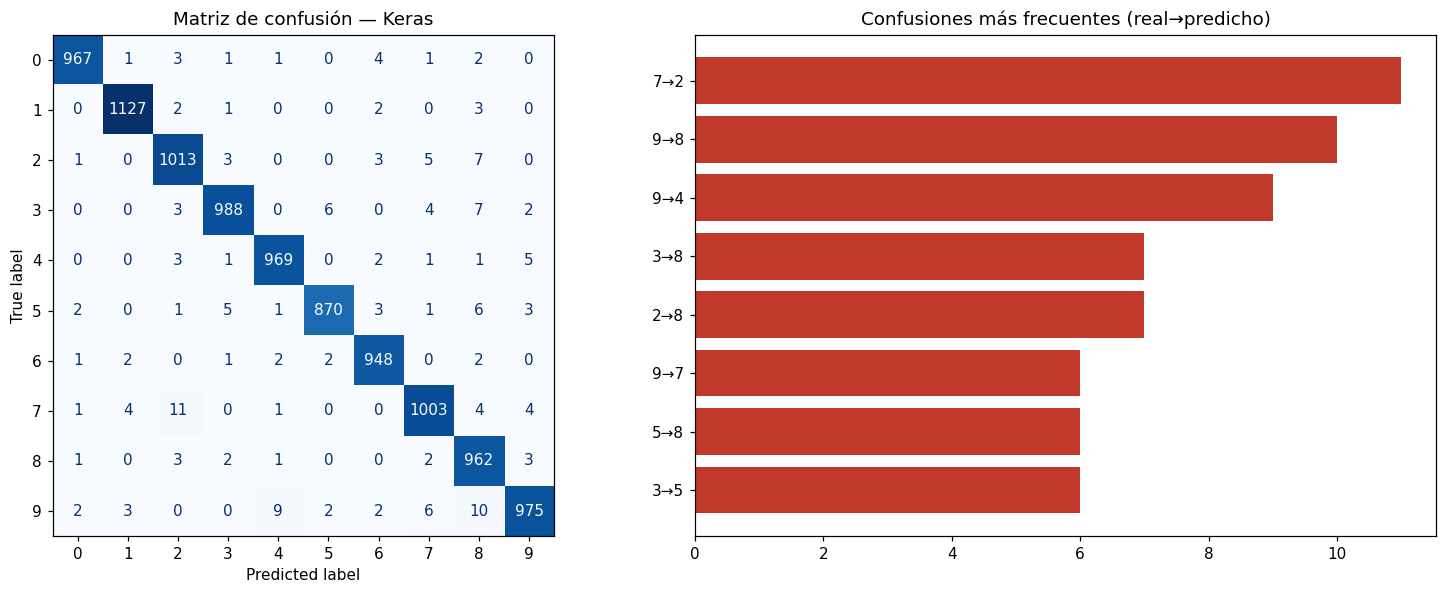

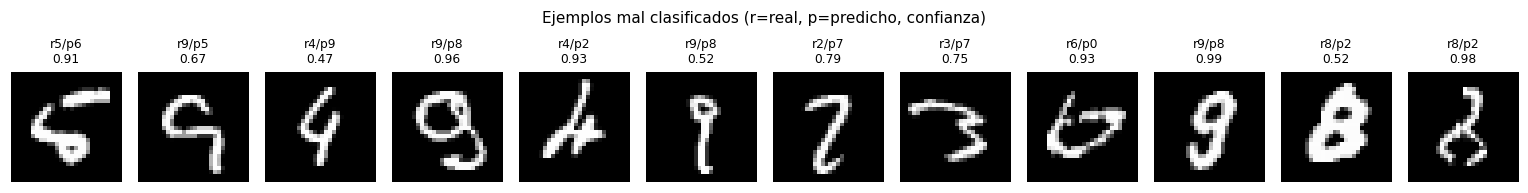

In [7]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(1, 2, figsize=(14, 5.5))
ConfusionMatrixDisplay(cm).plot(ax=ax[0], cmap="Blues", colorbar=False, values_format="d")
ax[0].set_title("Matriz de confusión — Keras")
cm_off = cm.copy(); np.fill_diagonal(cm_off, 0)
pairs = sorted(((cm_off[i, j], i, j) for i in range(10) for j in range(10)), reverse=True)[:8]
ax[1].barh([f"{i}→{j}" for _, i, j in pairs][::-1], [n for n, _, _ in pairs][::-1], color="#c0392b")
ax[1].set_title("Confusiones más frecuentes (real→predicho)")
plt.tight_layout(); plt.savefig("figures/03_confusion_keras.png", bbox_inches="tight"); plt.show()

wrong = np.where(y_pred != y_test)[0][:12]
fig, axes = plt.subplots(1, 12, figsize=(14, 1.9))
for a, i in zip(axes, wrong):
    a.imshow(x_test[i], cmap="gray"); a.axis("off"); a.set_title(f"r{y_test[i]}/p{y_pred[i]}\n{probs[i].max():.2f}", fontsize=8)
plt.suptitle("Ejemplos mal clasificados (r=real, p=predicho, confianza)", fontsize=10)
plt.tight_layout(); plt.savefig("figures/03_errores_keras.png", bbox_inches="tight"); plt.show()

In [8]:
results = {"framework": "TensorFlow + Keras", "version": tf.__version__, "test_accuracy": float(test_acc),
           "test_loss": float(test_loss), "epochs": len(history.history["loss"]), "train_time_s": round(train_time, 1),
           "params": int(model.count_params()), "errors": int((y_pred != y_test).sum()),
           "val_accuracy_best": float(max(history.history["val_accuracy"])),
           "history": {k: [float(v) for v in vals] for k, vals in history.history.items()},
           "activation_experiment": {k: [float(v) for v in hh["val_accuracy"]] for k, hh in act_hist.items()}}
json.dump(results, open("results/keras_mnist.json", "w"), indent=2)
model.save("results/mlp_mnist_keras.keras")
print({k: v for k, v in results.items() if k not in ("history", "activation_experiment")})

{'framework': 'TensorFlow + Keras', 'version': '2.21.0', 'test_accuracy': 0.982200026512146, 'test_loss': 0.06255536526441574, 'epochs': 12, 'train_time_s': 24.6, 'params': 235146, 'errors': 178, 'val_accuracy_best': 0.9828333258628845}


## 5. Análisis

* Un MLP de 2 capas ocultas (≈ 235 mil parámetros) supera el **98 % de exactitud en test** sin convoluciones, sólo con píxeles aplanados.
* **ReLU vs Sigmoide:** con idéntica arquitectura y optimizador, ReLU alcanza mayor exactitud desde la primera época porque su gradiente no se atenúa al pasar por las capas.
* **Dropout + EarlyStopping** mantienen cercanas las curvas de entrenamiento y validación y detienen el entrenamiento cuando la pérdida de validación deja de mejorar.
* Las confusiones más frecuentes se dan entre dígitos de trazo parecido: 7→2, 9→8, 9→4 y 3→8 (ver gráfico de barras). Un MLP no aprovecha la estructura espacial local de la imagen; esa es la limitación que resuelven las CNN, fuera del alcance de esta actividad.